### 5.2 LDA model

In [ ]:
# Parameters
n_topics = 13
ngram_range = (1, 2)

# =========================
# VECTORIZATION (Count)
# =========================
vectorizer = CountVectorizer(
    stop_words=STOPWORDS,
    ngram_range=ngram_range,
    min_df=0.005,
    max_df=0.7
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# LDA
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=100,
    random_state=42,
    learning_method="online"
)

W = lda.fit_transform(X)   
H = lda.components_      

# Topics
def print_topics(H, feature_names, topk=10):
    for i, topic in enumerate(H):
        top_words = [feature_names[j] for j in topic.argsort()[-topk:][::-1]]
        print(f"Topic {i}: {' | '.join(top_words)}")

print("\n===== TOPICS =====")
print_topics(H, feature_names)



===== TOPICS =====
Topic 0: majorité | mitterrand | françois | françois mitterrand | socialiste | président | mai | république | unie | donner
Topic 1: gauche | mitterrand | lutte | falloir | travailleur | député | majorité | gouvernement | homme | même
Topic 2: liberté | national | public | front | enseignement | majorité | patrie | devoir | populaire | battre
Topic 3: nucléaire | écologiste | gauche | devoir | énergie | falloir | femme | travail | vie | populaire
Topic 4: communiste | gauche | parti | parti communiste | changement | majorité | union | monsieur | voix | gouvernement
Topic 5: national | vote | front national | député | avenir | électeur | front | conviction | liste | confiance
Topic 6: falloir | réussir | blée | assem | assem blée | majorité | blée national | victoire | place | communiste
Topic 7: liberté | socialiste | majorité | union | 14 | 1981 | société | vouloir | national | 14 juin
Topic 8: accepter | europe | grand | pouvoir accepter | celer | financier | temp

In [ ]:
topic_titles_lda = [
    "Socialist Majority",     
    "Left-wing Politics",     
    "Liberty & Nationalism",   
    "Ecology & Energy",        
    "Communist Politics",      
    "National Front",         
    "Political Success / Victory", 
    "Socialist Agenda 1981",   
    "Europe & Power",          
    "Economic & Labour Rights",
    "Workers & Communist Movements", 
    "RPR & Right-wing",        
    "Local Governance / Duties"
]

In [8]:
partis = df["parti"]
annees = df["year"]    

In [27]:
topic_titles = ['Majorité présidentielle',
 'Dynamique de gauche',
 'Patriotisme',
 'Ecologie',
 'Radicalité de gauche',
 'Extrême droite',
 'Action parlementaire',
 'Union de la gauche',
 'Europe',
 'Economie',
 'Travail',
 'Droite',
 'Administration locale']

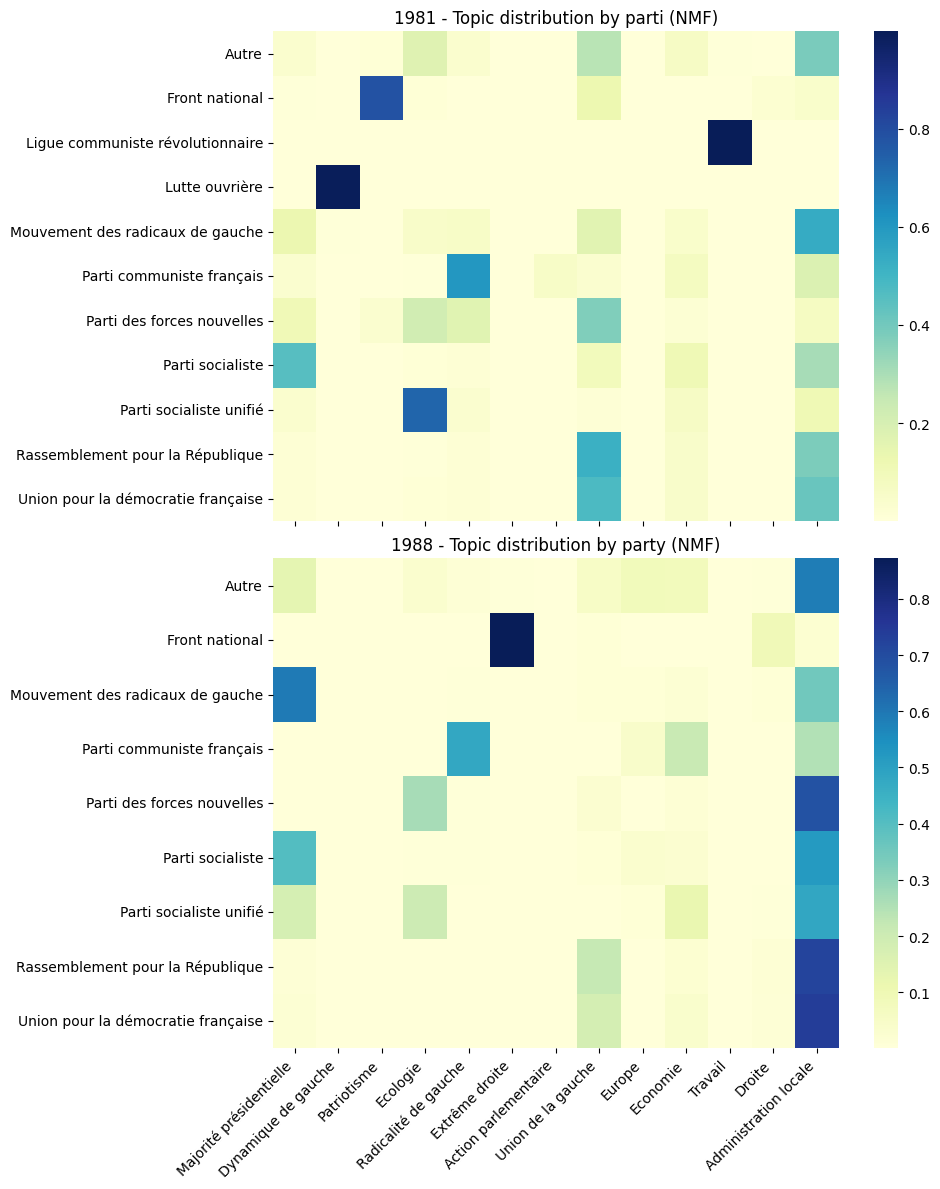

In [ ]:
df2 = pd.DataFrame(W, columns=[f"topic_{i}" for i in range(n_topics)])
df2["parti"] = partis
df2["annee"] = annees  # ⚠️ important : 1981 / 1988

topic_parti_annee = df2.groupby(["annee", "parti"]).mean()

topic_81 = topic_parti_annee.loc[1981]
topic_88 = topic_parti_annee.loc[1988]

# 3 HEATMAPS 1981 vs 1988
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# 1981
sns.heatmap(topic_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by parti (NMF)")
axes[0].set_ylabel(None)

# 1988
sns.heatmap(topic_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (NMF)")
axes[1].set_ylabel(None)
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("lda_results.png",dpi=300)
plt.show()